In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib.dates as mdates
import statsmodels.formula.api as smf
import sys
sys.path.append('..')
from config import DATA_DIR, FIGURES_DIR


In [2]:
df = pd.read_csv(f"{DATA_DIR}/df.csv", index_col=0, parse_dates=True)
%store -r input_features

df_train = df[:"2024-12-31"]
df_test = df["2025-01-01":]
df_train_clean = df_train.dropna(subset=["net_load"] + input_features)
df_test_clean = df_test.dropna(subset=["net_load"] + input_features)

chaque régréssion quantile prendra des input features différentes. Pour chaque quantile on choisis les inputs par backward sélection:
 - on fit une régréssion quantile linéaire sur toutes les features préselectionné
 - on retire la features avec la plus grande p-value si celle-ci est plus grande que 5%
 - on réitère la procédure jusqu'à que toutes les features aient des pvalue en dessous de 5%.

In [3]:
def backward_elimination_quantreg(
    data, target, features, q, max_iter=500, threshold=0.05
):
    """
    Effectue une sélection de variables par élimination arrière pour smf.quantreg.
    """
    remaining_features = list(features)

    while len(remaining_features) > 0:
        # Construction de la formule dynamique
        formula = f"{target} ~ {' + '.join(remaining_features)} - 1"

        # Fit du modèle
        model = smf.quantreg(formula, data=data).fit(q=q, max_iter=max_iter)

        # Extraction des p-values (en ignorant l'intercept si présent)
        p_values = model.pvalues
        max_p_value = p_values.max()
        worst_feature = p_values.idxmax()

        if max_p_value > threshold:
            remaining_features.remove(worst_feature)
        else:
            break

    return remaining_features

On choisie de faire la régréssion quantile pour les quantile 5%, 10% etc.

In [4]:
n = 19
quantiles = np.linspace(1 / (n + 1), n / (n + 1), n)
quantile_input_features = {}  # les features sélectionnée pour le quantile q
quantile_reg = {}  # le modele fité pour le quantile q

In [5]:
# séléction des features et entrainement
for q in quantiles:
    q_round = round(q, 2)
    quantile_input_features[q] = backward_elimination_quantreg(
        df_train_clean, "net_load", input_features, q
    )
    formula = f"net_load ~ {' + '.join(quantile_input_features[q])} + 0"
    quantile_reg[q_round] = smf.quantreg(formula, data=df_train_clean).fit(
        q=q, max_iter=25000
    )


C:\Users\clemc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\clemc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\clemc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\clemc\AppData\Local

# Results

## Results on training data 

In [6]:
quantile_value = {}
for q in quantiles:
    q_round = round(q, 2)
    quantile_value[q_round] = quantile_reg[q_round].predict(df_train_clean)

pred_df = pd.DataFrame(quantile_value, index=df_train_clean.index)
sorted_pred_matrix = np.sort(pred_df.values, axis=1)


def get_cdf_value(y_observed, quantile_row):
    # i/n logic based on your specific formula
    idx = np.searchsorted(quantile_row, y_observed)
    return idx / n


df_train_clean["cdf_value"] = [
    get_cdf_value(y, row)
    for y, row in zip(df_train_clean["net_load"], sorted_pred_matrix)
]

### Probabilistic calibration

1. Visual test

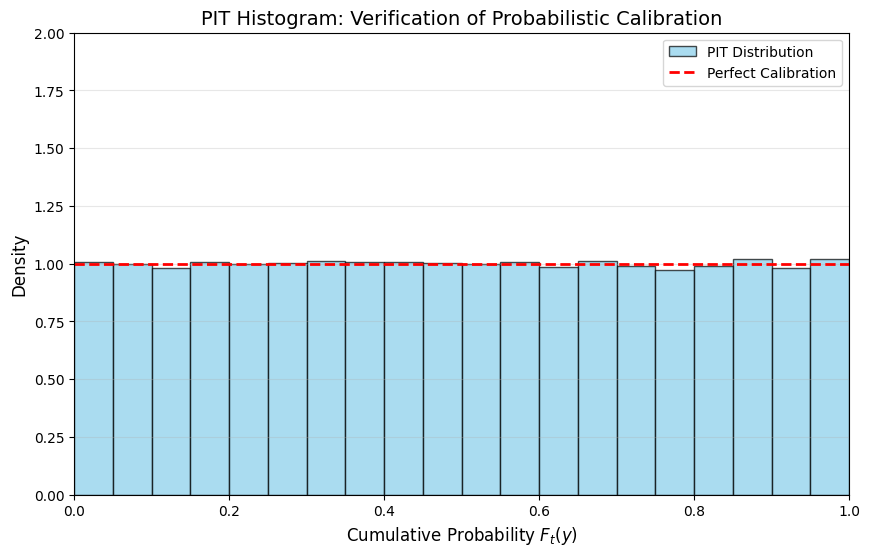

In [7]:
# 1. Create the plot
plt.figure(figsize=(10, 6))
n_bins = 20  # Typically matches or slightly exceeds your 'n' quantiles

# 2. Plot the distribution of your CDF values
plt.hist(
    df_train_clean["cdf_value"],
    bins=n_bins,
    density=True,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="PIT Distribution",
)

# 3. Add the theoretical Uniform(0,1) line
plt.axhline(
    y=1.0, color="red", linestyle="--", linewidth=2, label="Perfect Calibration"
)

# 4. Formatting
plt.title("PIT Histogram: Verification of Probabilistic Calibration", fontsize=14)
plt.xlabel("Cumulative Probability $F_t(y)$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 2)  # Helps visualize deviations from the 1.0 line
plt.legend()
plt.grid(axis="y", alpha=0.3)

# ✅ Save figure
plt.savefig(f"{FIGURES_DIR}/pit_histogramme.png", dpi=300, bbox_inches="tight")

plt.show()

2. Chi2-test

In [14]:
from scipy.stats import chisquare

# 1. Définition des 20 bins (de 0 à 1 par pas de 0.05)
bins = np.linspace(0, 1, 21)

# 2. Calcul des fréquences observées dans chaque bin
observed_counts, _ = np.histogram(df_train_clean["cdf_value"], bins=bins)

# 3. Calcul des fréquences théoriques (Uniformité parfaite)
# Chaque bin devrait contenir (Nombre total / 20) observations
total_obs = len(df_train_clean["cdf_value"])
expected_counts = np.full(20, total_obs / 20)

# 4. Exécution du test du Chi-deux
stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi2 statistics : {stat:.4f}")
print(f"P-value : {p_value:.4f}")

Chi2 statistics : 1.3722
P-value : 1.0000


# Reserve dimensioning

$$R_t \ge F^{-1}(1-\epsilon) - E_t$$

Where $E_t$ is the netload forecast (point forecast). We have 3 different value possible:
- mean
- median
- forecast provided by ENTSOE

We choose forecast provided by ENTSOE because its the one used in practice

In [15]:
epsilons = [(i + 1) / 100 for i in range(15)]
eps_input_features = {}
eps_reg = {}
for eps in epsilons:
    eps_input_features[1 - eps] = backward_elimination_quantreg(
        df_train_clean, "net_load", input_features, 1 - eps
    )
    formula = f"net_load ~ {' + '.join(eps_input_features[1 - eps])} + 0"
    eps_reg[eps] = smf.quantreg(formula, data=df_train_clean).fit(
        q=1 - eps, max_iter=25000
    )

eps_value = {}
for eps in epsilons:
    eps_value[eps] = eps_reg[eps].predict(df_test_clean)
pred_df = pd.DataFrame(eps_value, index=df_test_clean.index)
sorted_pred_matrix = np.sort(pred_df.values, axis=1)

C:\Users\clemc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\clemc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\clemc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
C:\Users\clemc\AppData\Local

In [16]:
for eps, predictions in eps_value.items():
    df_test_clean[f"quantile_1-{eps:.2f}"] = predictions

### graphs

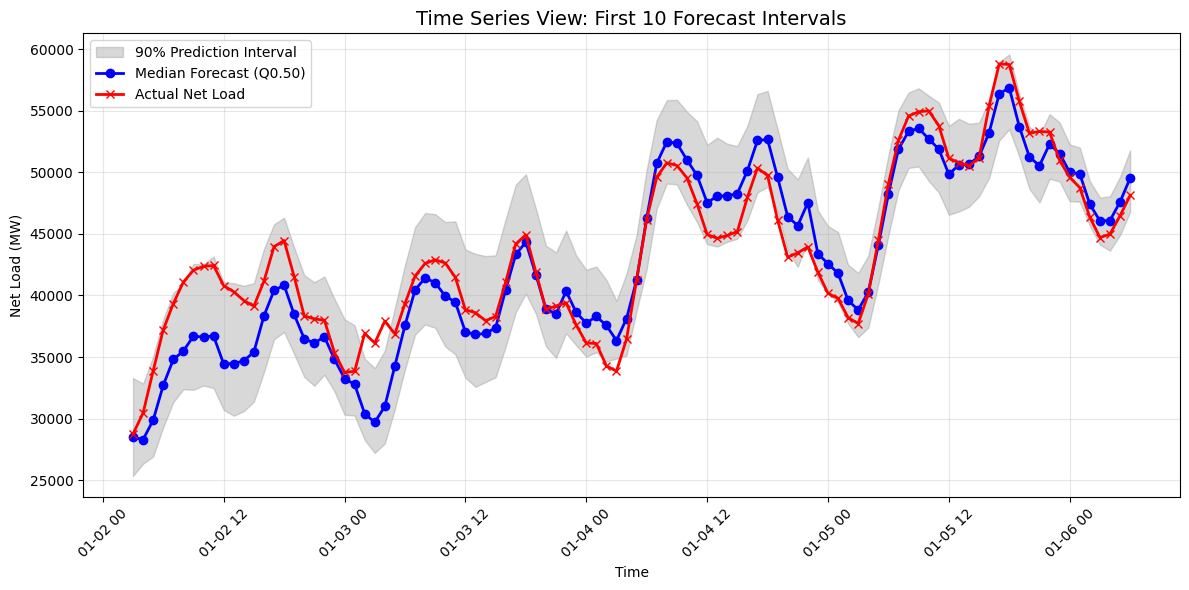

In [24]:
L = 100
# 1. Select the first L rows
df_plot = df_train_clean.head(L).copy()
# Extract the corresponding L rows from your sorted prediction matrix
# (Assuming sorted_pred_matrix was built from df_clean)
preds_plot = sorted_pred_matrix[:L, :]

# 2. Extract specific quantiles for plotting
# For 15 columns: index 1 -> 8.3% (lower), index 7 -> 50% (median), index 13 -> 93.3% (upper)
q_low = preds_plot[:, 1]
q_med = preds_plot[:, 7]
q_high = preds_plot[:, 13]

# 3. Plotting
plt.figure(figsize=(12, 6))

# Plot the 90% Prediction Interval (The "Cloud")
plt.fill_between(
    df_plot.index,
    q_low,
    q_high,
    color="gray",
    alpha=0.3,
    label="90% Prediction Interval",
)

# Plot the Median Forecast
plt.plot(
    df_plot.index,
    q_med,
    color="blue",
    marker="o",
    label="Median Forecast (Q0.50)",
    linewidth=2,
)

# Plot the Actual Observed Net Load
plt.plot(
    df_plot.index,
    df_plot["net_load"],
    color="red",
    marker="x",
    label="Actual Net Load",
    linewidth=2,
)

# 4. Formatting
plt.title("Time Series View: First 10 Forecast Intervals", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Results on test data

In [25]:
quantile_value = {}
for q in quantiles:
    q_round = round(q, 2)
    quantile_value[q_round] = quantile_reg[q_round].predict(df_test_clean)

pred_df = pd.DataFrame(quantile_value, index=df_test_clean.index)
sorted_pred_matrix = np.sort(pred_df.values, axis=1)


def get_cdf_value(y_observed, quantile_row):
    # i/n logic based on your specific formula
    idx = np.searchsorted(quantile_row, y_observed)
    return idx / n


df_test_clean["cdf_value"] = [
    get_cdf_value(y, row)
    for y, row in zip(df_test_clean["net_load"], sorted_pred_matrix)
]

/tmp/ipykernel_17417/142055873.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_clean["cdf_value"] = [


### Probabilistic calibration

#### 1. visual test

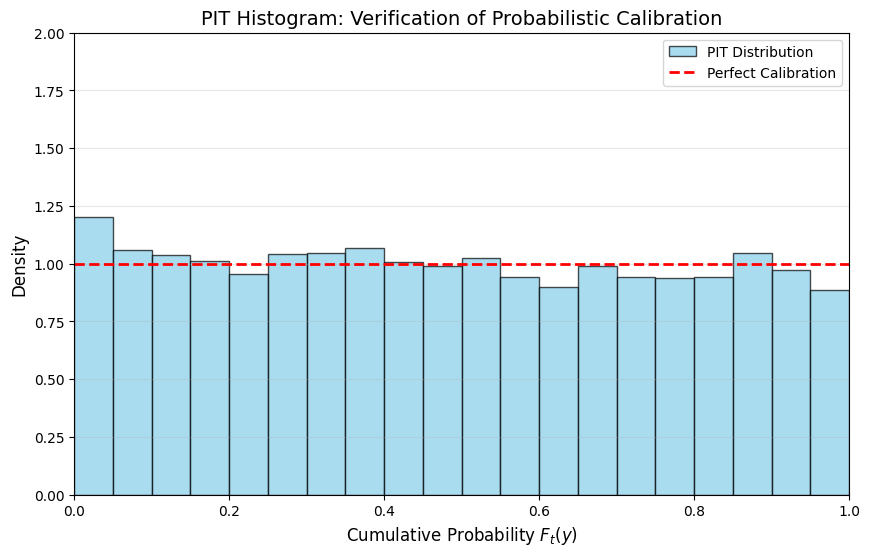

In [26]:
# 1. Create the plot
plt.figure(figsize=(10, 6))
n_bins = 20  # Typically matches or slightly exceeds your 'n' quantiles

# 2. Plot the distribution of your CDF values
plt.hist(
    df_test_clean["cdf_value"],
    bins=n_bins,
    density=True,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="PIT Distribution",
)

# 3. Add the theoretical Uniform(0,1) line
plt.axhline(
    y=1.0, color="red", linestyle="--", linewidth=2, label="Perfect Calibration"
)

# 4. Formatting
plt.title("PIT Histogram: Verification of Probabilistic Calibration", fontsize=14)
plt.xlabel("Cumulative Probability $F_t(y)$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 2)  # Helps visualize deviations from the 1.0 line
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

#### 2. chi_2 test

In [27]:
import numpy as np
import pandas as pd
from scipy.stats import chisquare

# 1. Définition des 20 bins (de 0 à 1 par pas de 0.05)
bins = np.linspace(0, 1, 21)

# 2. Calcul des fréquences observées dans chaque bin
observed_counts, _ = np.histogram(df_test_clean["cdf_value"], bins=bins)

# 3. Calcul des fréquences théoriques (Uniformité parfaite)
# Chaque bin devrait contenir (Nombre total / 20) observations
total_obs = len(df_test_clean["cdf_value"])
expected_counts = np.full(20, total_obs / 20)

# 4. Exécution du test du Chi-deux
stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Chi2 statistics : {stat:.4f}")
print(f"P-value : {p_value:.4f}")

Chi2 statistics : 38.8096
P-value : 0.0047


### marginal calibration

### graphs

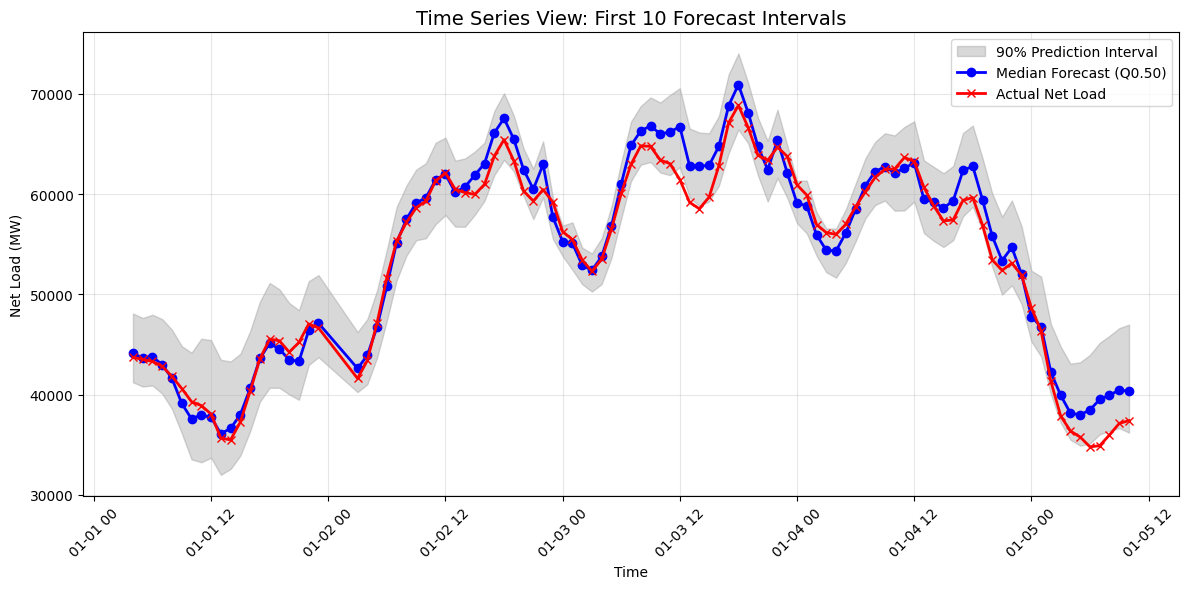

In [28]:
L = 100
# 1. Select the first L rows
df_plot = df_test_clean.head(L).copy()
# Extract the corresponding L rows from your sorted prediction matrix
# (Assuming sorted_pred_matrix was built from df_clean)
preds_plot = sorted_pred_matrix[:L, :]

# 2. Extract specific quantiles for plotting
# For 15 columns: index 1 -> 8.3% (lower), index 7 -> 50% (median), index 13 -> 93.3% (upper)
q_low = preds_plot[:, 1]
q_med = preds_plot[:, 7]
q_high = preds_plot[:, 13]

# 3. Plotting
plt.figure(figsize=(12, 6))

# Plot the 90% Prediction Interval (The "Cloud")
plt.fill_between(
    df_plot.index,
    q_low,
    q_high,
    color="gray",
    alpha=0.3,
    label="90% Prediction Interval",
)

# Plot the Median Forecast
plt.plot(
    df_plot.index,
    q_med,
    color="blue",
    marker="o",
    label="Median Forecast (Q0.50)",
    linewidth=2,
)

# Plot the Actual Observed Net Load
plt.plot(
    df_plot.index,
    df_plot["net_load"],
    color="red",
    marker="x",
    label="Actual Net Load",
    linewidth=2,
)

# 4. Formatting
plt.title("Time Series View: First 10 Forecast Intervals", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Net Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Reserve dimensionning

$$R_t \ge F^{-1}(1-epsilon) - E_t$$

Where $E_t$ is the netload forecast (point forecast). We have 3 different value possible:
 - mean
 - median
 - forecast provided by ENTSOE

We choose forecast provided by ENTSOE because its the one used in practice

In [29]:
epsilons = [(i + 1) / 100 for i in range(15)]
eps_input_features = {}  # les features sélectionnée pour le quantile 1-eps
eps_reg = {}
for eps in epsilons:
    eps_input_features[1 - eps] = backward_elimination_quantreg(
        df_train_clean, "net_load", input_features, 1 - eps
    )
    formula = f"net_load ~ {' + '.join(eps_input_features[1 - eps])} + 0"
    eps_reg[eps] = smf.quantreg(formula, data=df_train_clean).fit(
        q=1 - eps, max_iter=25000
    )

eps_value = {}
for eps in epsilons:
    eps_value[eps] = eps_reg[eps].predict(df_test_clean)
pred_df = pd.DataFrame(eps_value, index=df_test_clean.index)
sorted_pred_matrix = np.sort(pred_df.values, axis=1)

/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (500) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/opt/python/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: Iter

In [30]:
for eps, predictions in eps_value.items():
    df_test_clean[f"quantile_1-{eps:.2f}"] = predictions

/tmp/ipykernel_17417/861584640.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_clean[f"quantile_1-{eps:.2f}"] = predictions
/tmp/ipykernel_17417/861584640.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_clean[f"quantile_1-{eps:.2f}"] = predictions
/tmp/ipykernel_17417/861584640.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

## Calculation of R

In [31]:
Rs = []
for eps in epsilons:
    df_test_clean[f"R({eps:.2f})"] = df_test_clean[f"quantile_1-{eps:.2f}"] - (
        df_test_clean["DA_load"] - df_test_clean["DA_renewable"]
    )
    v = (
        df_test_clean["net_load"]
        - (df_test_clean["DA_load"] - df_test_clean["DA_renewable"])
        > df_test_clean[f"R({eps:.2f})"]
    ).mean()
    print(f"evaluation de P(error>R({eps:.2f})) = {v}")
    Rs.append(f"R({eps:.2f})")

evaluation de P(error>R(0.01)) = 0.0070052539404553416
evaluation de P(error>R(0.02)) = 0.01451088316237178
evaluation de P(error>R(0.03)) = 0.025894420815611708
evaluation de P(error>R(0.04)) = 0.0355266449837378
evaluation de P(error>R(0.05)) = 0.04428321240930698
evaluation de P(error>R(0.06)) = 0.05741806354766075
evaluation de P(error>R(0.07)) = 0.0668001000750563
evaluation de P(error>R(0.08)) = 0.07505629221916438
evaluation de P(error>R(0.09)) = 0.08381285964473355
evaluation de P(error>R(0.10)) = 0.09294470853139855
evaluation de P(error>R(0.11)) = 0.10382787090317738
evaluation de P(error>R(0.12)) = 0.11183387540655491
evaluation de P(error>R(0.13)) = 0.12159119339504629
evaluation de P(error>R(0.14)) = 0.13510132599449587
evaluation de P(error>R(0.15)) = 0.14523392544408306


/tmp/ipykernel_17417/599942831.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_clean[f"R({eps:.2f})"] = df_test_clean[f"quantile_1-{eps:.2f}"] - (
/tmp/ipykernel_17417/599942831.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_clean[f"R({eps:.2f})"] = df_test_clean[f"quantile_1-{eps:.2f}"] - (
/tmp/ipykernel_17417/599942831.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [32]:
df_test_clean[Rs].to_csv(f"{DATA_DIR}/Rs.csv", index=True)

## Evaluation of quantile

### 1.simple verification que X<=Quantile(a) dans environ a cas 

### 2. Christoffersen's test: unconditionnal coverage and independance

### 3.Engle & Manganelli's Dynamic Quantile

# Average reserve level for epsilon=0.01

In [33]:
# for this part we choose epsilon=0.01

average_reserve = df_test_clean[Rs]["R(0.01)"].mean()
average_reserve

np.float64(5493.332198991764)

# Frequency of under coverage

In [34]:
(
    df_test_clean["net_load"]
    - (df_test_clean["DA_load"] - df_test_clean["DA_renewable"])
    > df_test_clean["R(0.01)"]
).sum() / len(df_test_clean)

np.float64(0.0070052539404553416)

# Total reserve cost

In [35]:
df_reserves = pd.read_csv(f"{DATA_DIR}/procured_reserves.csv", sep=";")
df_reserves

,Date,Heures,Type de réserve,Type de produit,Sens de la réserve,Quantité contractualisée (en MW),Prix de la réserve (en euros/MW/15min),Temporalité
0,01/01/2025,00:00 - 00:15,Réserve primaire,STD,A la hausse et à la baisse,670,"0,69",Journalier
1,01/01/2025,00:00 - 00:15,Réserve secondaire,STD,A la hausse,713,"5,39",Journalier
2,01/01/2025,00:00 - 00:15,Réserve secondaire,STD,A la baisse,755,"5,39",Journalier
3,01/01/2025,00:00 - 00:15,Réserve rapide,SPE0,A la hausse,405,"0,03",Journalier
4,01/01/2025,00:00 - 00:15,Réserve rapide,SPE0,A la hausse,651,"0,31",Annuel
...,...,...,...,...,...,...,...,...
208297,30/12/2025,00:00 - 00:15,Réserve secondaire,STD,A la hausse,701,"2,68",Journalier
208298,30/12/2025,00:00 - 00:15,Réserve secondaire,STD,A la baisse,758,"2,74",Journalier
208299,30/12/2025,00:00 - 00:15,Réserve rapide,SPE0,A la hausse,556,"0,43",Journalier
208300,30/12/2025,00:00 - 00:15,Réserve rapide,SPE0,A la hausse,607,"0,42",Périodique


In [36]:
# df['price_eur_15min']=df['price_eur_mw_15min']*df['quantity_mw']
# df.head()



In [37]:
df = df_reserves.copy()

# Rename columns for convenience
df.columns = [
    "date",
    "time_slot",
    "reserve_type",
    "product_type",
    "direction",
    "quantity_mw",
    "price_eur_mw_15min",
    "temporality",
]

# Convert price column from string to numeric
df["price_eur_mw_15min"] = (
    df["price_eur_mw_15min"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Extract start time from 15-min slot and build datetime
df["start_time"] = df["time_slot"].str.slice(0, 5)
df["datetime"] = pd.to_datetime(df["date"] + " " + df["start_time"], dayfirst=True)

# Floor to 1-hour resolution
df["hour"] = df["datetime"].dt.floor("H")

# Group by day and hour, sum prices
hourly_price_sum = (
    df.groupby(df["hour"])["price_eur_mw_15min"]
    .sum()
    .reset_index(name="hourly_price_eur_mw")
)

hourly_price_sum.head()

/tmp/ipykernel_17417/2322226222.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour"] = df["datetime"].dt.floor("H")


,hour,hourly_price_eur_mw
0,2025-01-01 00:00:00,47.36
1,2025-01-01 01:00:00,44.24
2,2025-01-01 02:00:00,28.52
3,2025-01-01 03:00:00,28.28
4,2025-01-01 04:00:00,25.36


In [38]:
average_reserve_cost = hourly_price_sum["hourly_price_eur_mw"].mean()
print("Average reserve cost per hour per MW:", average_reserve_cost)

print("Average reserve cost per hour:", average_reserve_cost * average_reserve)

Average reserve cost per hour per MW: 69.78276744719926
Average reserve cost per hour: 383339.92335245403


# Idem for epsilon=0.01 to 0.15

In [39]:
df_test_clean[Rs]

,R(0.01),R(0.02),R(0.03),R(0.04),R(0.05),R(0.06),R(0.07),R(0.08),R(0.09),R(0.10),R(0.11),R(0.12),R(0.13),R(0.14),R(0.15)
2025-01-01 04:00:00+00:00,7785.160702,7103.436362,6894.859596,6801.161079,6384.170043,6142.526201,5820.259017,5760.689952,5412.112398,5409.154302,5224.314844,5124.322955,4985.596551,4624.776142,4651.950847
2025-01-01 05:00:00+00:00,8214.978938,7414.264342,7228.111940,7186.662355,6779.719080,6536.858354,6197.271243,6137.477052,5754.262285,5782.886902,5570.629260,5453.561180,5323.009230,4942.347181,5015.862350
2025-01-01 06:00:00+00:00,8518.006886,7556.066830,7309.531465,7249.029882,6839.092717,6596.828663,6259.118406,6151.254483,5780.277143,5776.969349,5527.315268,5401.709382,5261.750252,4888.549509,4983.454234
2025-01-01 07:00:00+00:00,8800.273988,7750.486656,7460.768776,7406.927120,6891.568225,6663.593841,6331.312403,6157.852726,5827.808381,5760.210708,5486.413143,5365.314996,5214.245084,4850.603018,4910.785386
2025-01-01 08:00:00+00:00,9373.315475,8158.521886,7860.412761,7825.575343,7261.061735,7038.150962,6694.223041,6524.853010,6146.806155,6105.202570,5808.692142,5669.840689,5527.868132,5151.940999,5215.986514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30 19:00:00+00:00,3615.674397,2882.426666,2436.186803,2085.962323,2031.056334,1876.927883,1762.734510,1544.421586,1537.233373,1341.169756,1258.355633,1160.642017,1089.486529,1210.550532,1044.952584
2025-11-30 20:00:00+00:00,3384.958584,3027.800279,2697.688423,2355.339585,2218.337335,2066.352255,1930.571553,1685.984451,1737.782141,1447.717785,1407.067551,1355.100362,1230.752042,1338.608094,1228.197760
2025-11-30 21:00:00+00:00,3683.159353,3576.993653,3466.038123,3308.595278,3118.004336,2964.259019,2776.908970,2591.908429,2597.820889,2376.462429,2370.842947,2318.855347,2212.306350,2263.464286,2045.000678
2025-11-30 22:00:00+00:00,3905.600640,3551.684688,3297.305293,3113.146961,2940.016863,2789.295634,2626.323700,2383.165895,2405.329902,2154.363157,2100.963603,2025.416265,1927.097240,1990.793468,1693.390549


In [40]:
average_reserves = df_test_clean[Rs].mean()

In [41]:
# Define epsilon values
epsilons = np.round(np.arange(0.01, 0.16, 0.01), 2)

# Precompute forecast error (actual − forecast)
forecast_error = df_test_clean["net_load"] - (
    df_test_clean["DA_load"] - df_test_clean["DA_renewable"]
)

# Compute under-coverage frequency for each epsilon
under_coverage_freq = []

for eps in epsilons:
    col = f"R({eps:.2f})"
    freq = (forecast_error > df_test_clean[col]).sum() / len(df_test_clean)
    under_coverage_freq.append(freq)

# Store results in a DataFrame
df_under_coverage = pd.DataFrame(
    {"epsilon": epsilons, "under_coverage_frequency": under_coverage_freq}
)

df_under_coverage

,epsilon,under_coverage_frequency
0,0.01,0.007005
1,0.02,0.014511
2,0.03,0.025894
3,0.04,0.035527
4,0.05,0.044283
5,0.06,0.057418
6,0.07,0.066800
7,0.08,0.075056
8,0.09,0.083813
9,0.10,0.092945


In [42]:
df_average_reserve_cost = pd.DataFrame(
    {
        "epsilon": epsilons,
        "average_reserve_cost": average_reserves * average_reserve_cost,
    }
)
df_average_reserve_cost

,epsilon,average_reserve_cost
R(0.01),0.01,383339.923352
R(0.02),0.02,335574.434696
R(0.03),0.03,303075.638721
R(0.04),0.04,283516.225787
R(0.05),0.05,267267.190661
R(0.06),0.06,252725.541600
R(0.07),0.07,240221.359075
R(0.08),0.08,228368.649728
R(0.09),0.09,219609.516803
R(0.10),0.10,209432.023823


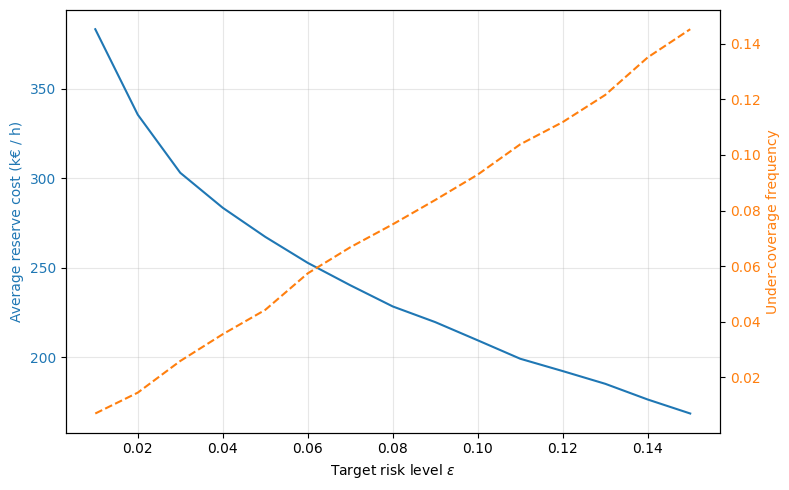

In [43]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

# ---- Curve 1: Average reserve cost (blue) ----
ax1.plot(
    df_average_reserve_cost["epsilon"],
    df_average_reserve_cost["average_reserve_cost"] / 1e3,
    color="tab:blue",
)
ax1.set_xlabel("Target risk level $\\varepsilon$")
ax1.set_ylabel("Average reserve cost (k€ / h)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# ---- Curve 2: Under-coverage frequency (orange, dashed) ----
ax2 = ax1.twinx()
ax2.plot(
    df_under_coverage["epsilon"],
    df_under_coverage["under_coverage_frequency"],
    linestyle="--",
    color="tab:orange",
)
ax2.set_ylabel("Under-coverage frequency", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# ---- Title ----
# plt.title("Cost–reliability trade-off for reserve dimensioning")

# ✅ Save figure
plt.savefig(f"{FIGURES_DIR}/cost_reliability.png", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()